# Credit Card Fraud Detection
**Models:** Logistic Regression | Random Forest | Neural Network (ANN)

In [1]:
#Import all libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)

print('All libraries imported successfully!')

All libraries imported successfully!


In [2]:
# Load Dataset
df = pd.read_csv('creditcard.csv')
print('Shape:', df.shape)
df.head()

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
#EDA
print(f'Rows         : {df.shape[0]}')
print(f'Columns      : {df.shape[1]}')
print(f'Missing vals : {df.isnull().sum().sum()}')
print(f'Duplicates   : {df.duplicated().sum()}')

fraud_count = df['Class'].value_counts()
print(f'\nNon-Fraud: {fraud_count[0]:,} ({fraud_count[0]/len(df)*100:.2f}%)')
print(f'Fraud    : {fraud_count[1]:,} ({fraud_count[1]/len(df)*100:.2f}%)')

Rows         : 284807
Columns      : 31
Missing vals : 0
Duplicates   : 1081

Non-Fraud: 284,315 (99.83%)
Fraud    : 492 (0.17%)


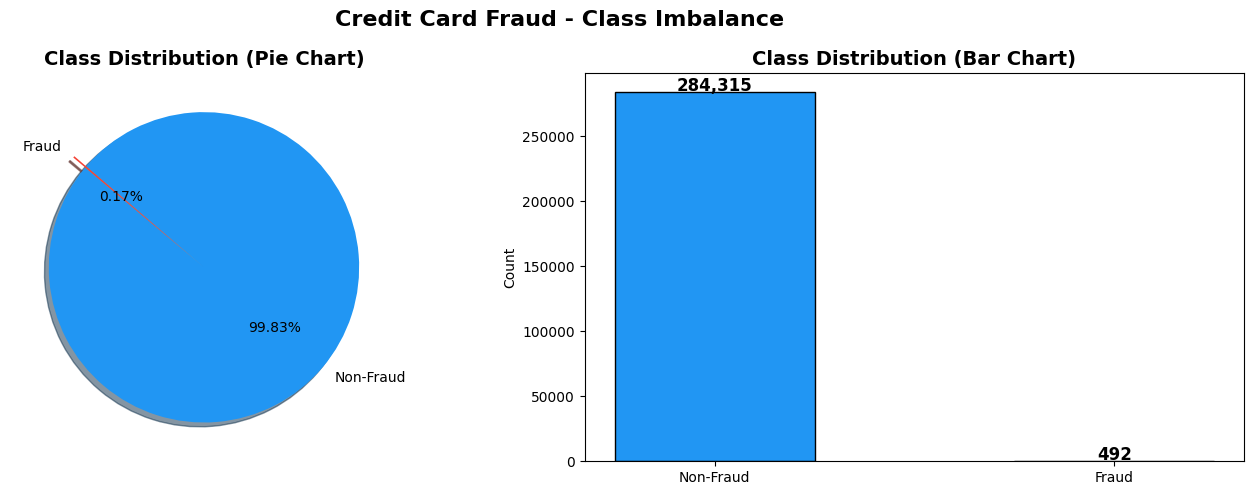

Saved: 01_class_distribution.png


In [4]:
#Pie Chart + Bar Chart
fraud_count = df['Class'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].pie(fraud_count, labels=['Non-Fraud','Fraud'],
    autopct='%1.2f%%', colors=['#2196F3','#F44336'],
    startangle=140, explode=(0,0.1), shadow=True)
axes[0].set_title('Class Distribution (Pie Chart)', fontsize=14, fontweight='bold')

bars = axes[1].bar(['Non-Fraud','Fraud'], fraud_count.values,
    color=['#2196F3','#F44336'], edgecolor='black', width=0.5)
for bar in bars:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+500,
        f'{bar.get_height():,}', ha='center', fontsize=12, fontweight='bold')
axes[1].set_title('Class Distribution (Bar Chart)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count')

plt.suptitle('Credit Card Fraud - Class Imbalance', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 01_class_distribution.png')

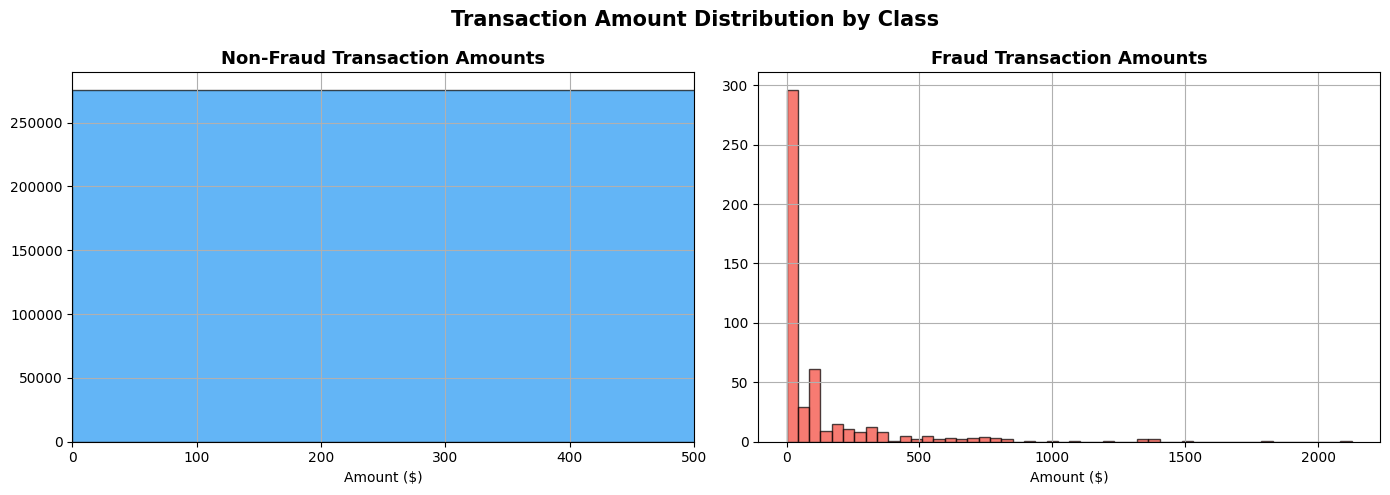

Saved: 02_amount_distribution.png


In [5]:
# STEP 3c - Amount Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df[df['Class']==0]['Amount'].hist(bins=50, ax=axes[0], color='#2196F3', alpha=0.7, edgecolor='black')
axes[0].set_title('Non-Fraud Transaction Amounts', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Amount ($)')
axes[0].set_xlim(0, 500)

df[df['Class']==1]['Amount'].hist(bins=50, ax=axes[1], color='#F44336', alpha=0.7, edgecolor='black')
axes[1].set_title('Fraud Transaction Amounts', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Amount ($)')

plt.suptitle('Transaction Amount Distribution by Class', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('02_amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 02_amount_distribution.png')

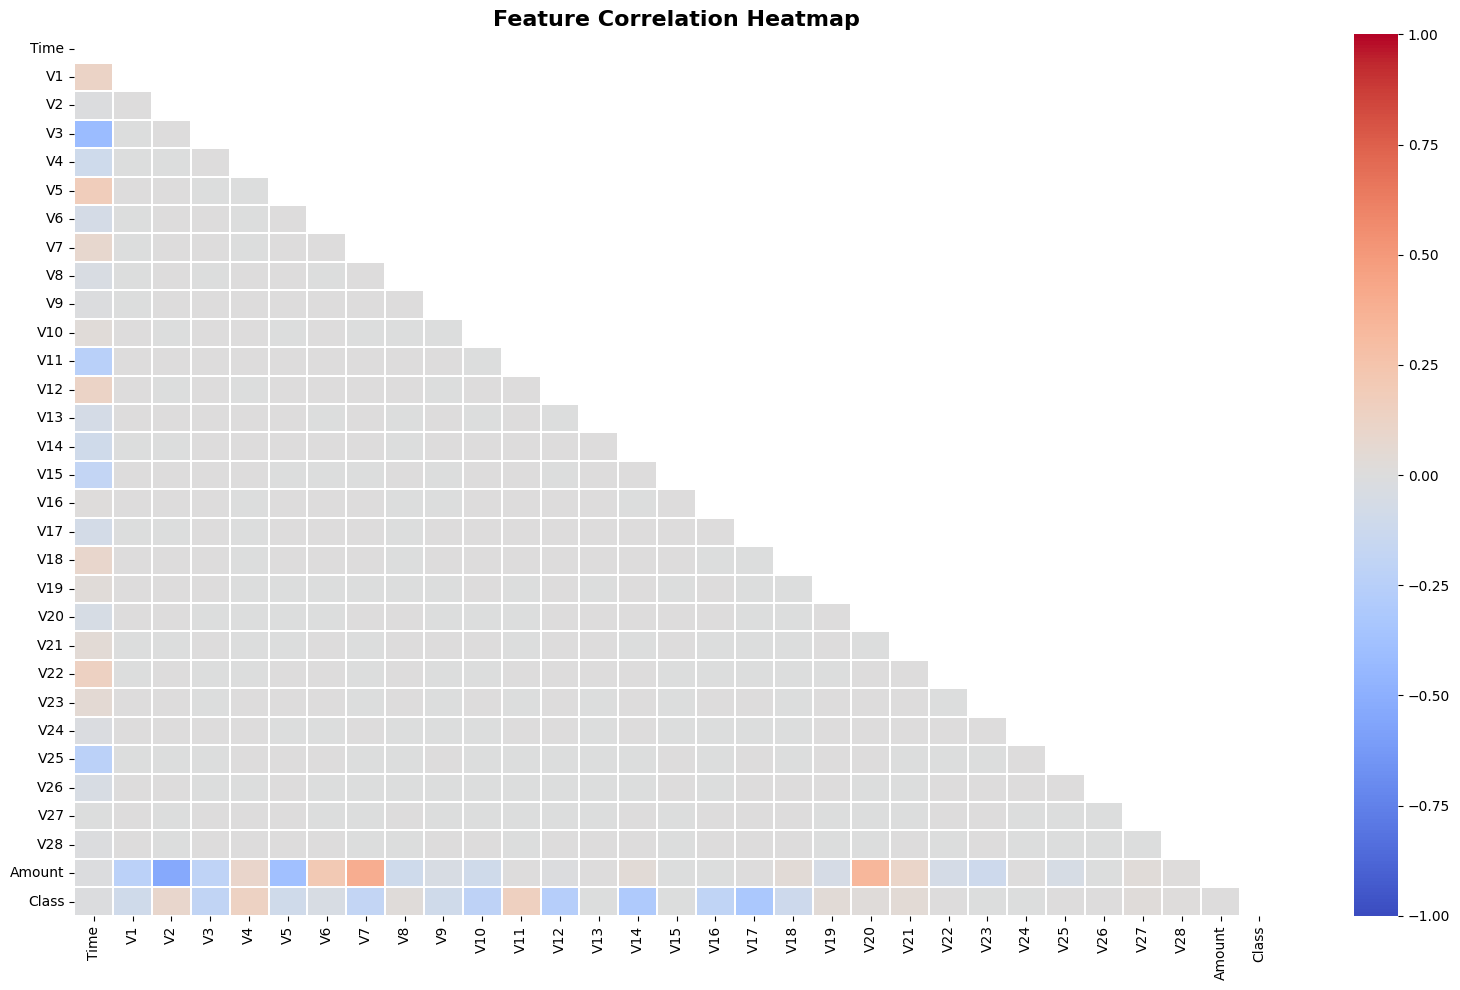

Saved: 03_correlation_heatmap.png


In [6]:
#Correlation Heatmap
plt.figure(figsize=(16, 10))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm',
    linewidths=0.3, vmin=-1, vmax=1, center=0)
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('03_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 03_correlation_heatmap.png')

In [7]:
#Data Cleaning & Preprocessing
before = len(df)
df.drop_duplicates(inplace=True)
print(f'Removed {before - len(df)} duplicates')

scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled']   = scaler.fit_transform(df[['Time']])
df.drop(columns=['Amount','Time'], inplace=True)

X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Training set : {X_train.shape[0]} samples')
print(f'Test set     : {X_test.shape[0]} samples')

Removed 1081 duplicates
Training set : 226980 samples
Test set     : 56746 samples


SMOTE applied!
Class
0    226602
1     22660
Name: count, dtype: int64


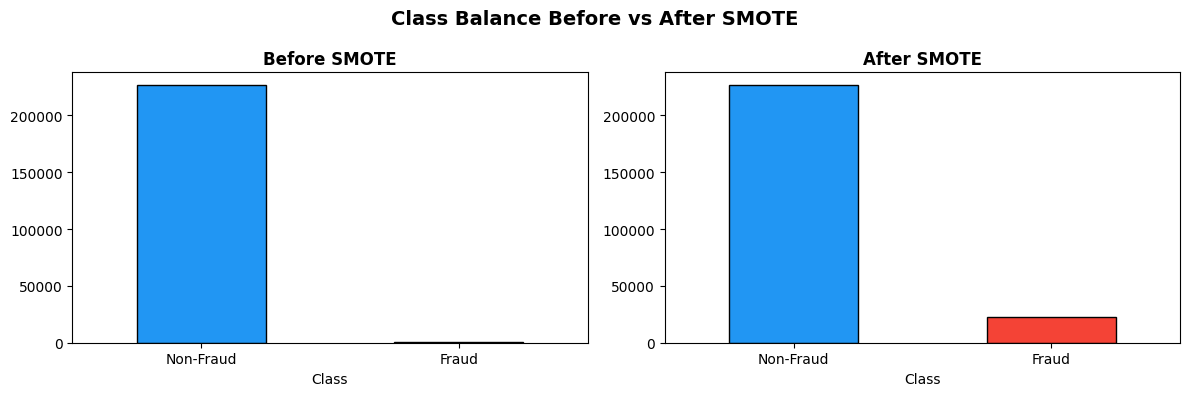

Saved: 04_smote_balance.png


In [8]:
# Apply SMOTE
smote = SMOTE(random_state=42, sampling_strategy=0.1, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('SMOTE applied!')
print(pd.Series(y_train_sm).value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pd.Series(y_train).value_counts().plot(kind='bar', ax=axes[0],
    color=['#2196F3','#F44336'], edgecolor='black')
axes[0].set_title('Before SMOTE', fontweight='bold')
axes[0].set_xticklabels(['Non-Fraud','Fraud'], rotation=0)

pd.Series(y_train_sm).value_counts().plot(kind='bar', ax=axes[1],
    color=['#2196F3','#F44336'], edgecolor='black')
axes[1].set_title('After SMOTE', fontweight='bold')
axes[1].set_xticklabels(['Non-Fraud','Fraud'], rotation=0)

plt.suptitle('Class Balance Before vs After SMOTE', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('04_smote_balance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 04_smote_balance.png')

In [9]:
# STEP 5 - Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_sm, y_train_sm)

lr_pred = lr_model.predict(X_test)
lr_prob = lr_model.predict_proba(X_test)[:,1]

lr_acc  = accuracy_score(y_test, lr_pred)
lr_prec = precision_score(y_test, lr_pred)
lr_rec  = recall_score(y_test, lr_pred)
lr_f1   = f1_score(y_test, lr_pred)

print('='*45)
print('      LOGISTIC REGRESSION RESULTS')
print('='*45)
print(f'  Accuracy  : {lr_acc:.4f}')
print(f'  Precision : {lr_prec:.4f}')
print(f'  Recall    : {lr_rec:.4f}')
print(f'  F1-Score  : {lr_f1:.4f}')
print('='*45)
print(classification_report(y_test, lr_pred, target_names=['Non-Fraud','Fraud']))

      LOGISTIC REGRESSION RESULTS
  Accuracy  : 0.9978
  Precision : 0.4199
  Recall    : 0.8000
  F1-Score  : 0.5507
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00     56651
       Fraud       0.42      0.80      0.55        95

    accuracy                           1.00     56746
   macro avg       0.71      0.90      0.77     56746
weighted avg       1.00      1.00      1.00     56746



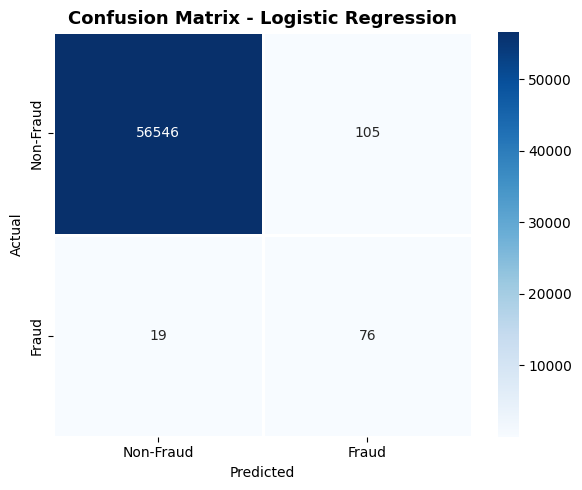

In [10]:
# Confusion Matrix - Logistic Regression
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, lr_pred), annot=True, fmt='d',
    cmap='Blues', xticklabels=['Non-Fraud','Fraud'],
    yticklabels=['Non-Fraud','Fraud'], linewidths=1, linecolor='white')
plt.title('Confusion Matrix - Logistic Regression', fontsize=13, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('05_cm_lr.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# STEP 6 - Random Forest
rf_model = RandomForestClassifier(
    n_estimators=50, random_state=42,
    class_weight='balanced', n_jobs=-1, max_depth=10)
rf_model.fit(X_train_sm, y_train_sm)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:,1]

rf_acc  = accuracy_score(y_test, rf_pred)
rf_prec = precision_score(y_test, rf_pred)
rf_rec  = recall_score(y_test, rf_pred)
rf_f1   = f1_score(y_test, rf_pred)

print('='*45)
print('          RANDOM FOREST RESULTS')
print('='*45)
print(f'  Accuracy  : {rf_acc:.4f}')
print(f'  Precision : {rf_prec:.4f}')
print(f'  Recall    : {rf_rec:.4f}')
print(f'  F1-Score  : {rf_f1:.4f}')
print('='*45)
print(classification_report(y_test, rf_pred, target_names=['Non-Fraud','Fraud']))

          RANDOM FOREST RESULTS
  Accuracy  : 0.9987
  Precision : 0.5736
  Recall    : 0.7789
  F1-Score  : 0.6607
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00     56651
       Fraud       0.57      0.78      0.66        95

    accuracy                           1.00     56746
   macro avg       0.79      0.89      0.83     56746
weighted avg       1.00      1.00      1.00     56746



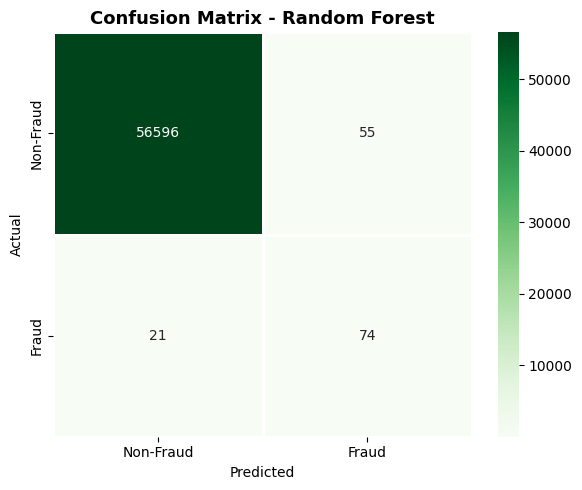

In [12]:
# Confusion Matrix - Random Forest
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d',
    cmap='Greens', xticklabels=['Non-Fraud','Fraud'],
    yticklabels=['Non-Fraud','Fraud'], linewidths=1, linecolor='white')
plt.title('Confusion Matrix - Random Forest', fontsize=13, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('06_cm_rf.png', dpi=150, bbox_inches='tight')
plt.show()

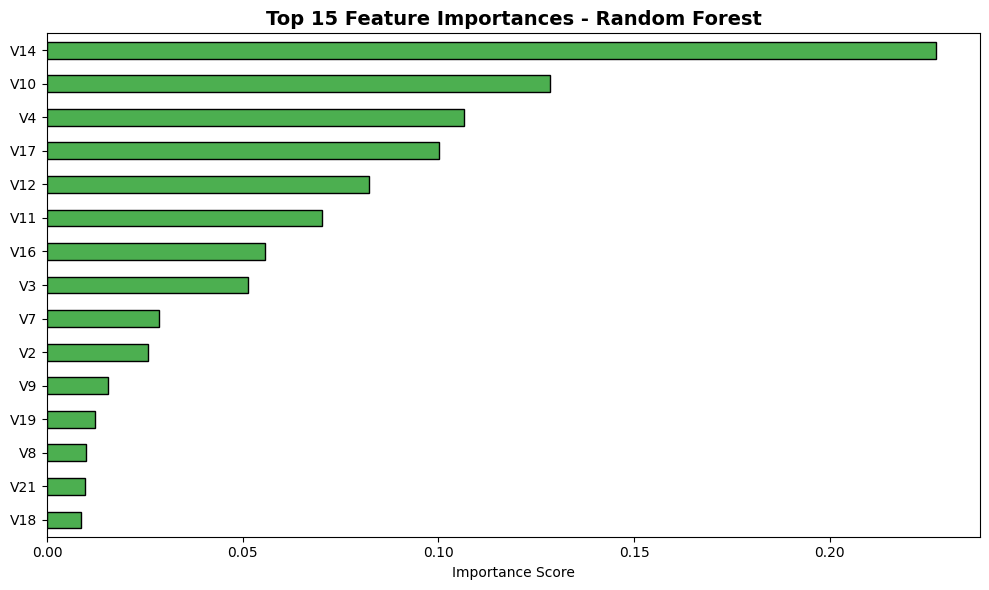

Saved: 07_feature_importance.png


In [13]:
# Feature Importance
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top15 = importances.nlargest(15)
plt.figure(figsize=(10,6))
top15.sort_values().plot(kind='barh', color='#4CAF50', edgecolor='black')
plt.title('Top 15 Feature Importances - Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('07_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 07_feature_importance.png')

In [14]:
# STEP 7 - Neural Network (ANN)
ann_model = MLPClassifier(
    hidden_layer_sizes=(64, 32, 16),
    activation='relu', solver='adam',
    max_iter=50, random_state=42,
    early_stopping=True, validation_fraction=0.1,
    n_iter_no_change=5, verbose=False)
ann_model.fit(X_train_sm, y_train_sm)

ann_pred = ann_model.predict(X_test)
ann_prob = ann_model.predict_proba(X_test)[:,1]

ann_acc  = accuracy_score(y_test, ann_pred)
ann_prec = precision_score(y_test, ann_pred)
ann_rec  = recall_score(y_test, ann_pred)
ann_f1   = f1_score(y_test, ann_pred)

print('='*45)
print('     NEURAL NETWORK (ANN) RESULTS')
print('='*45)
print(f'  Accuracy  : {ann_acc:.4f}')
print(f'  Precision : {ann_prec:.4f}')
print(f'  Recall    : {ann_rec:.4f}')
print(f'  F1-Score  : {ann_f1:.4f}')
print('='*45)
print(classification_report(y_test, ann_pred, target_names=['Non-Fraud','Fraud']))

     NEURAL NETWORK (ANN) RESULTS
  Accuracy  : 0.9992
  Precision : 0.7426
  Recall    : 0.7895
  F1-Score  : 0.7653
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00     56651
       Fraud       0.74      0.79      0.77        95

    accuracy                           1.00     56746
   macro avg       0.87      0.89      0.88     56746
weighted avg       1.00      1.00      1.00     56746



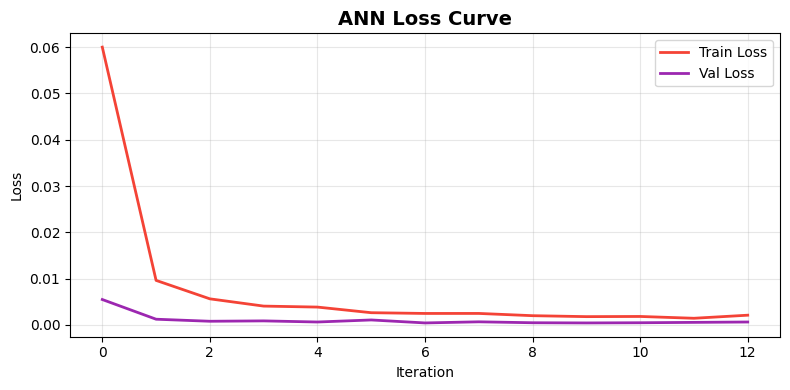

Saved: 08_ann_history.png


In [15]:
# ANN Loss Curve
plt.figure(figsize=(8,4))
plt.plot(ann_model.loss_curve_, color='#F44336', linewidth=2, label='Train Loss')
if ann_model.validation_scores_ is not None:
    val_loss = [1-s for s in ann_model.validation_scores_]
    plt.plot(val_loss, color='#9C27B0', linewidth=2, label='Val Loss')
plt.title('ANN Loss Curve', fontsize=14, fontweight='bold')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('08_ann_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 08_ann_history.png')

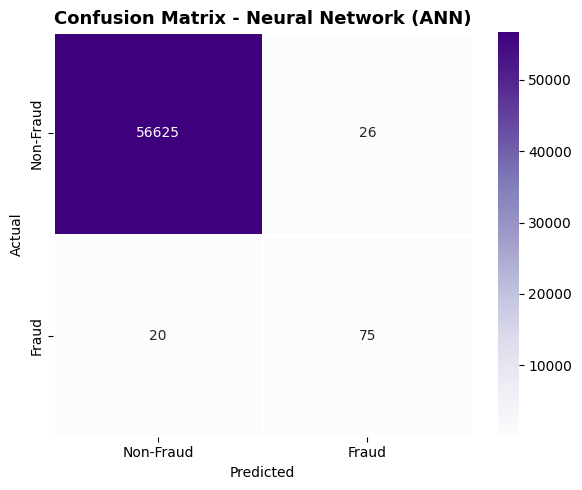

In [16]:
# Confusion Matrix - ANN
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, ann_pred), annot=True, fmt='d',
    cmap='Purples', xticklabels=['Non-Fraud','Fraud'],
    yticklabels=['Non-Fraud','Fraud'], linewidths=1, linecolor='white')
plt.title('Confusion Matrix - Neural Network (ANN)', fontsize=13, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('09_cm_ann.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# STEP 8 - Comparison Table
results = pd.DataFrame({
    'Model':     ['Logistic Regression','Random Forest','Neural Network (ANN)'],
    'Accuracy':  [lr_acc,  rf_acc,  ann_acc],
    'Precision': [lr_prec, rf_prec, ann_prec],
    'Recall':    [lr_rec,  rf_rec,  ann_rec],
    'F1-Score':  [lr_f1,   rf_f1,   ann_f1]
}).set_index('Model').round(4)

print('='*65)
print('            MODEL COMPARISON TABLE')
print('='*65)
print(results.to_string())
print('='*65)
best = results['F1-Score'].idxmax()
print(f'\nBest Model: {best} (F1={results.loc[best,"F1-Score"]:.4f}')

            MODEL COMPARISON TABLE
                      Accuracy  Precision  Recall  F1-Score
Model                                                      
Logistic Regression     0.9978     0.4199  0.8000    0.5507
Random Forest           0.9987     0.5736  0.7789    0.6607
Neural Network (ANN)    0.9992     0.7426  0.7895    0.7653

Best Model: Neural Network (ANN) (F1=0.7653


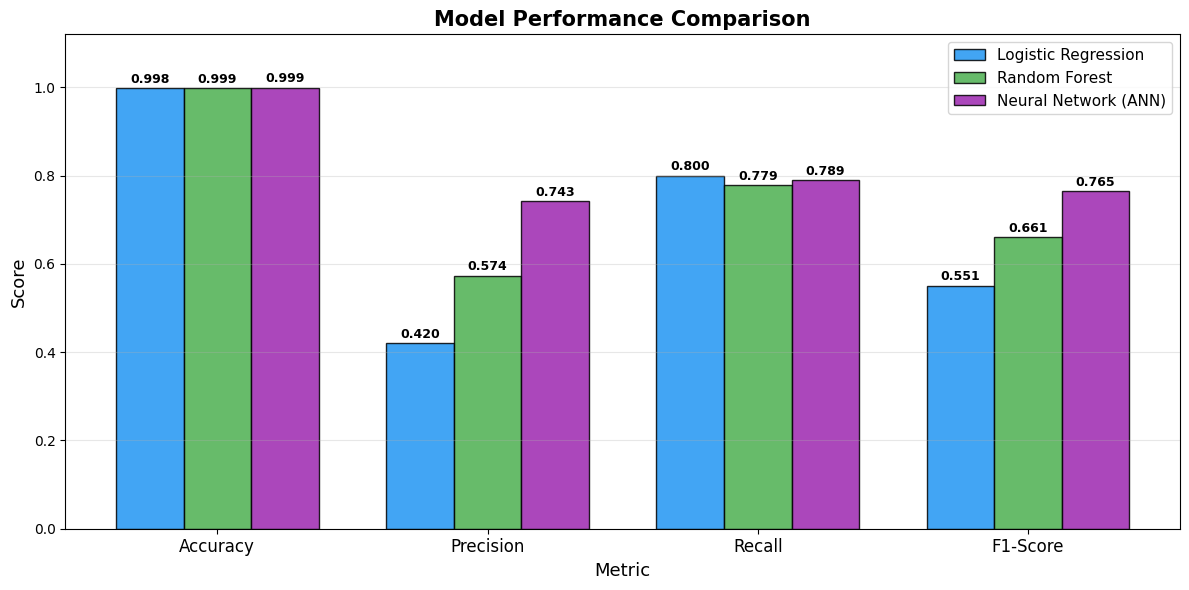

Saved: 10_model_comparison.png


In [18]:
# Grouped Bar Chart - All Metrics
metrics = ['Accuracy','Precision','Recall','F1-Score']
models  = results.index.tolist()
colors  = ['#2196F3','#4CAF50','#9C27B0']
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(12,6))
for i,(model,color) in enumerate(zip(models,colors)):
    vals = results.loc[model, metrics].values
    bars = ax.bar(x+i*width, vals, width, label=model, color=color, edgecolor='black', alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Metric', fontsize=13)
ax.set_ylabel('Score', fontsize=13)
ax.set_title('Model Performance Comparison', fontsize=15, fontweight='bold')
ax.set_xticks(x+width)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0,1.12)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('10_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 10_model_comparison.png')

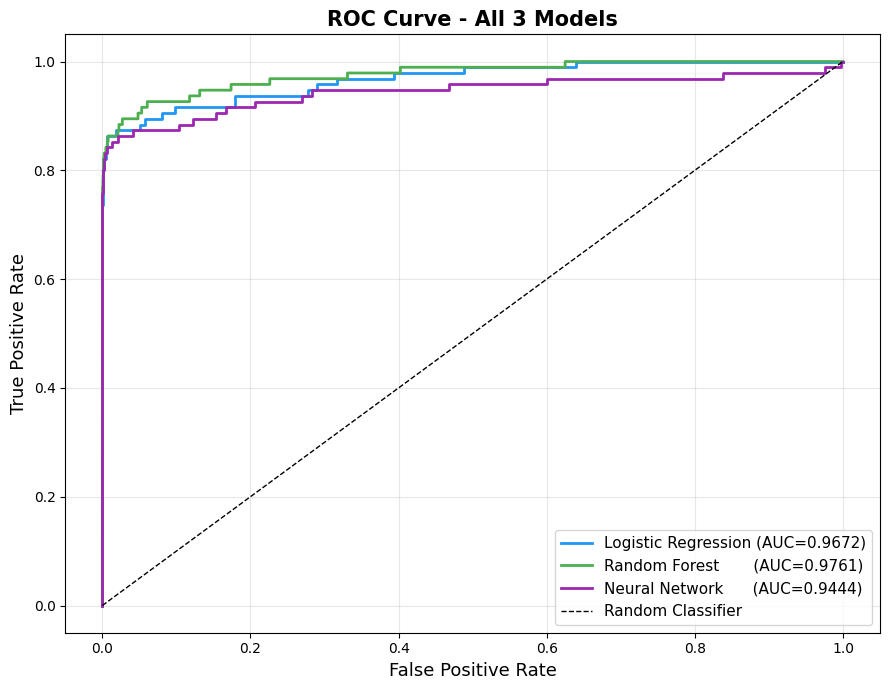

Saved: 11_roc_curves.png


In [19]:
# ROC Curves
fpr_lr,  tpr_lr,  _ = roc_curve(y_test, lr_prob)
fpr_rf,  tpr_rf,  _ = roc_curve(y_test, rf_prob)
fpr_ann, tpr_ann, _ = roc_curve(y_test, ann_prob)

plt.figure(figsize=(9,7))
plt.plot(fpr_lr,  tpr_lr,  label=f'Logistic Regression (AUC={auc(fpr_lr,tpr_lr):.4f})',  color='#2196F3', linewidth=2)
plt.plot(fpr_rf,  tpr_rf,  label=f'Random Forest       (AUC={auc(fpr_rf,tpr_rf):.4f})',  color='#4CAF50', linewidth=2)
plt.plot(fpr_ann, tpr_ann, label=f'Neural Network      (AUC={auc(fpr_ann,tpr_ann):.4f})', color='#9C27B0', linewidth=2)
plt.plot([0,1],[0,1],'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate',  fontsize=13)
plt.title('ROC Curve - All 3 Models', fontsize=15, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('11_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 11_roc_curves.png')

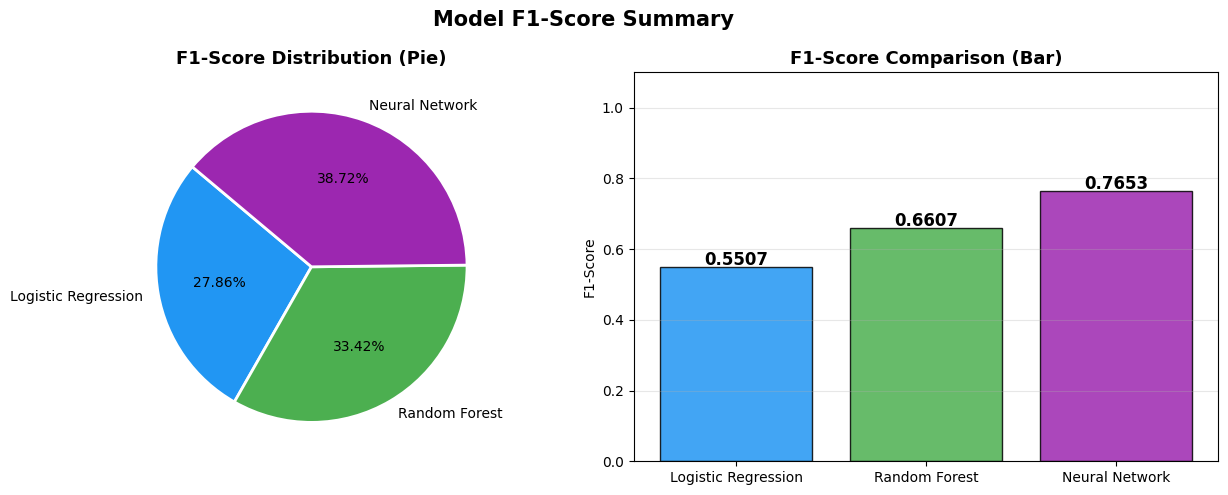

Saved: 12_f1_summary.png


In [20]:
# F1 Pie + Bar
f1_scores   = [lr_f1, rf_f1, ann_f1]
model_names = ['Logistic Regression','Random Forest','Neural Network']
colors_pie  = ['#2196F3','#4CAF50','#9C27B0']

fig, axes = plt.subplots(1, 2, figsize=(13,5))
axes[0].pie(f1_scores, labels=model_names, autopct='%1.2f%%',
    colors=colors_pie, startangle=140,
    wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('F1-Score Distribution (Pie)', fontsize=13, fontweight='bold')

bars = axes[1].bar(model_names, f1_scores, color=colors_pie, edgecolor='black', alpha=0.85)
for bar in bars:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
        f'{bar.get_height():.4f}', ha='center', fontsize=12, fontweight='bold')
axes[1].set_title('F1-Score Comparison (Bar)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('F1-Score')
axes[1].set_ylim(0,1.1)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Model F1-Score Summary', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('12_f1_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 12_f1_summary.png')

In [21]:
# STEP 9 - Final Verdict
print('='*55)
print('       FINAL MODEL EVALUATION SUMMARY')
print('='*55)
print(results.to_string())
print('='*55)
best = results['F1-Score'].idxmax()
print(f'''
BEST MODEL FOR DEPLOYMENT: {best}
  - Highest F1-Score (balanced precision and recall)
  - For fraud detection, Recall is critical
  - Deployment date: April 13, 2026
''')

       FINAL MODEL EVALUATION SUMMARY
                      Accuracy  Precision  Recall  F1-Score
Model                                                      
Logistic Regression     0.9978     0.4199  0.8000    0.5507
Random Forest           0.9987     0.5736  0.7789    0.6607
Neural Network (ANN)    0.9992     0.7426  0.7895    0.7653

BEST MODEL FOR DEPLOYMENT: Neural Network (ANN)
  - Highest F1-Score (balanced precision and recall)
  - For fraud detection, Recall is critical
  - Deployment date: April 13, 2026

